In [ ]:
import tensorflow as tf 
from tensorflow import keras 
import tensorflow_addons as tfa
import tensorflow_hub as hub 
from sklearn.metrics import mean_absolute_error 
import numpy as np 
import datetime
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Activation, Dense, Flatten, Conv2D, MaxPooling2D, AveragePooling2D, BatchNormalization, PReLU
import os
import warnings

# Ignore irrelevant warning messages for cleaner output
warnings.filterwarnings('ignore')

c:\Users\ALFIAN\anaconda3\envs\env_insightface\lib\site-packages\tensorflow_addons\utils\tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
c:\Users\ALFIAN\anaconda3\envs\env_insightface\lib\site-packages\tensorflow_addons\utils\ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.11.0 and strictly below 2.14.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.15.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do no

In [4]:
train_ds = tf.data.Dataset.load('C://Users//ALFIAN//TA_CODING//ZIP_FILE//arcface_oceanmodel//ocean-project-deepface//data//videoface_100//train_ds') \
    .cache().shuffle(buffer_size=1000, seed=42).prefetch(buffer_size=tf.data.AUTOTUNE)

valid_ds = tf.data.Dataset.load('C://Users//ALFIAN//TA_CODING//ZIP_FILE//arcface_oceanmodel//ocean-project-deepface//data//videoface_100//val_ds//12266908818711133995') \
    .cache().shuffle(buffer_size=1000, seed=42).prefetch(buffer_size=tf.data.AUTOTUNE)

train_ds, valid_ds

(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 10, 112, 112, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 5), dtype=tf.float32, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 10, 112, 112, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 5), dtype=tf.float32, name=None))>)

Load Arcface


In [5]:
from models import create_arcface_model

# Load dengan weights (default)
arcface_112 = create_arcface_model(load_weights=True)
arcface_112.trainable = False

arcface_112.summary()



⚠ Warning: Could not load weights from C://Users//ALFIAN//TA CODING//ZIP FILE//arcface_oceanmodel//ocean-project-deepface//arcface_weights.h5
  Error: [Errno 2] Unable to synchronously open file (unable to open file: name = 'C://Users//ALFIAN//TA CODING//ZIP FILE//arcface_oceanmodel//ocean-project-deepface//arcface_weights.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)
  Model will be initialized with random weights.
Model: "ArcFace"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 112, 112, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 114, 114, 3)          0         ['input_1[0][0]']             
                           

⚠ Warning: Could not load weights from C://Users//ALFIAN//TA CODING//ZIP FILE//arcface_oceanmodel//ocean-project-deepface//arcface_weights.h5
  Error: [Errno 2] Unable to synchronously open file (unable to open file: name = 'C://Users//ALFIAN//TA CODING//ZIP FILE//arcface_oceanmodel//ocean-project-deepface//arcface_weights.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)
  Model will be initialized with random weights.


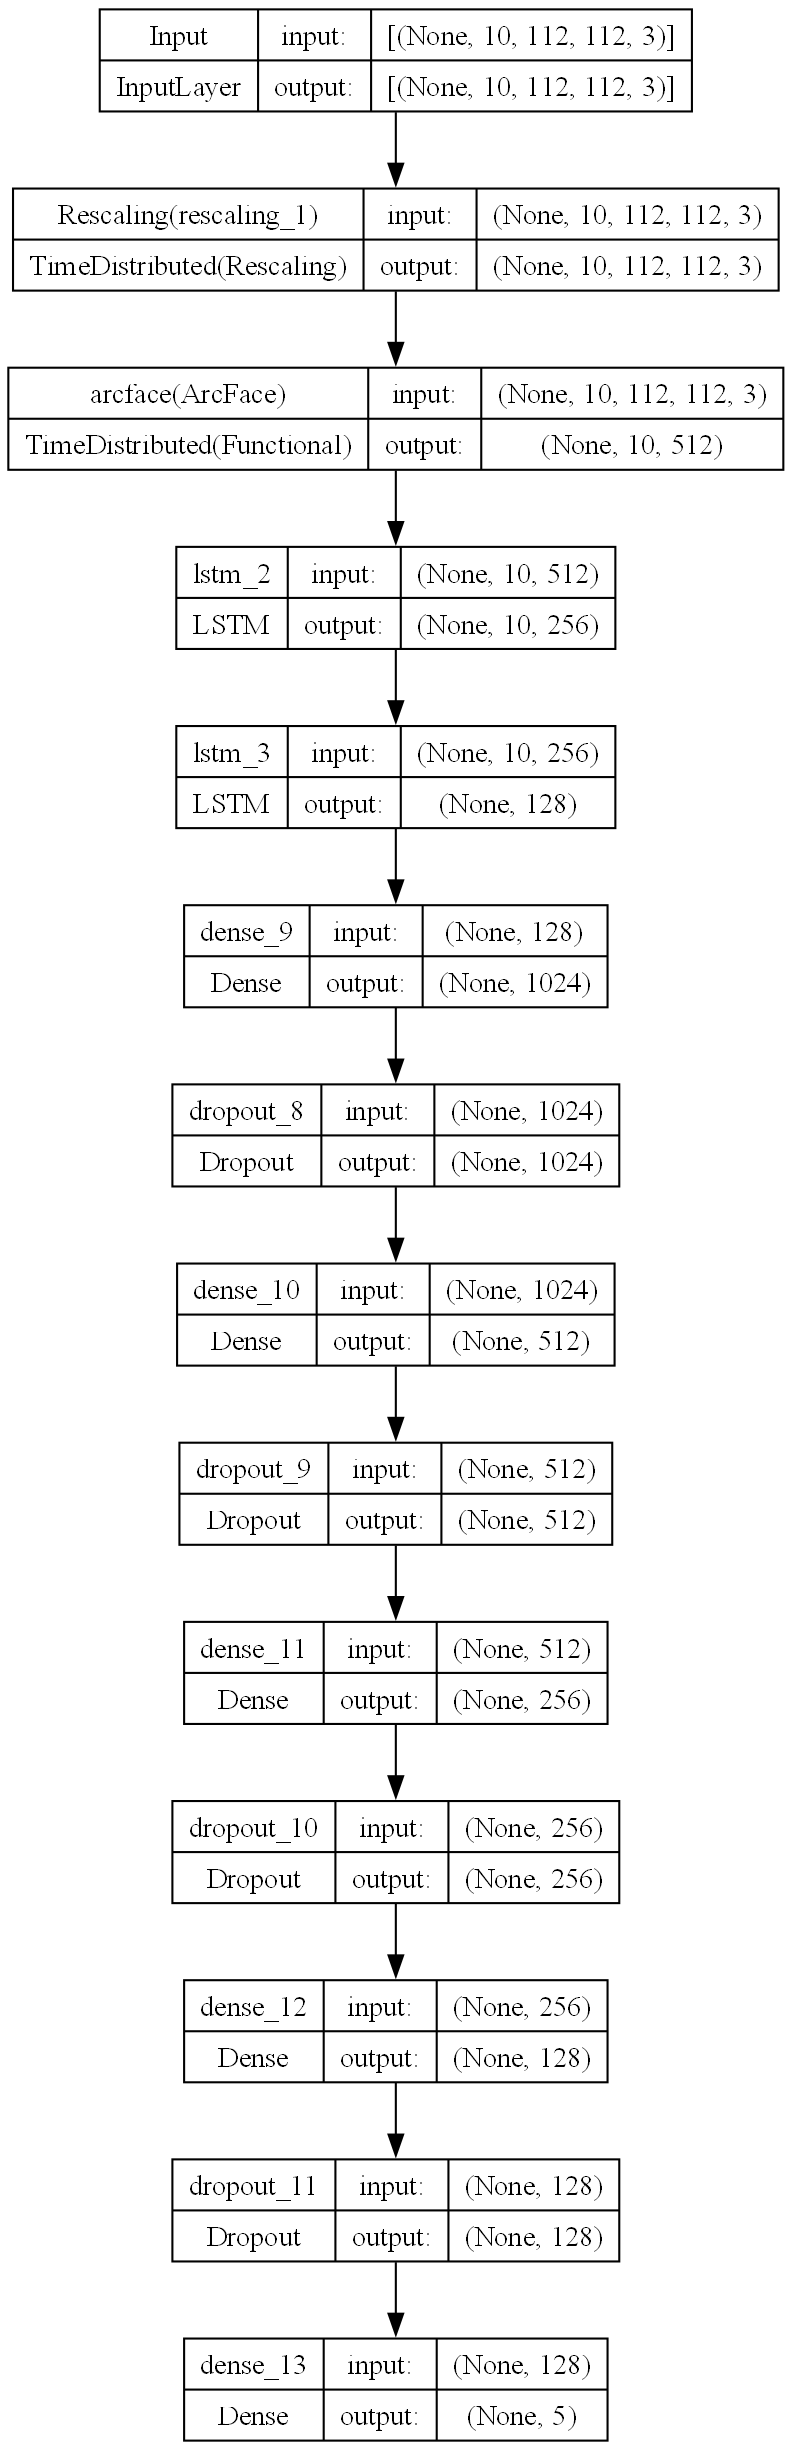


✅ MODEL UPGRADED SUCCESSFULLY!

📊 Model Changes:
   LSTM 1: 128 → 256 units ⭐
   LSTM 2: 64 → 128 units ⭐
   Dense layers: 1024 → 512 → 256 → 128 → 5 ⭐ (tambah layer 128)

   Total parameters: 35,971,525


In [8]:
from models import create_arcface_model
from tensorflow.keras import regularizers
from IPython.display import Image  # ⭐ TAMBAHKAN INI

# Load ArcFace model
arcface_112 = create_arcface_model()
arcface_112.trainable = False

# Build model dengan TimeDistributed untuk sequence input
inputs = keras.layers.Input(shape=(10, 112, 112, 3), name='Input')

# Preprocessing
x = keras.layers.TimeDistributed(keras.layers.Rescaling(scale=1./255.0), name='Rescaling')(inputs)

# ArcFace feature extractor (tetap dibekukan)
x = keras.layers.TimeDistributed(arcface_112, name='arcface')(x)

# ⭐ UPGRADE PRIORITAS 2: LSTM layers dengan units lebih besar
x = keras.layers.LSTM(units=256, return_sequences=True)(x)  # Dari 128 → 256
x = keras.layers.LSTM(units=128)(x)  # Dari 64 → 128

# Dense + Dropout + Regularization
x = keras.layers.Dense(1024, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
x = keras.layers.Dropout(0.3)(x)

x = keras.layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
x = keras.layers.Dropout(0.3)(x)

x = keras.layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
x = keras.layers.Dropout(0.5)(x)

# ⭐ UPGRADE PRIORITAS 2: Tambah layer Dense 128
x = keras.layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
x = keras.layers.Dropout(0.5)(x)

# Output
x = keras.layers.Dense(5, activation='sigmoid')(x)

# Build model
model = keras.models.Model(inputs=inputs, outputs=x)

# ⭐ PERBAIKAN: Plot model dengan save file + display
keras.utils.plot_model(
    model, 
    to_file='model_architecture.png',  # Simpan ke file
    show_shapes=True,
    show_layer_names=True,
    rankdir='TB',  # Top to Bottom
    dpi=150
)

# ⭐ Display gambar di notebook
display(Image('model_architecture.png'))

print("\n" + "=" * 80)
print("✅ MODEL UPGRADED SUCCESSFULLY!")
print("=" * 80)
print("\n📊 Model Changes:")
print("   LSTM 1: 128 → 256 units ⭐")
print("   LSTM 2: 64 → 128 units ⭐")
print("   Dense layers: 1024 → 512 → 256 → 128 → 5 ⭐ (tambah layer 128)")
print(f"\n   Total parameters: {model.count_params():,}")
print("=" * 80)


In [9]:
import datetime

# Timestamp untuk penamaan file
t = datetime.datetime.now().strftime("%m%d_%H%M%S")

# ============================================
# CALLBACKS (PRIORITAS 4 - UPGRADE)
# ============================================

# 1. EarlyStopping - stop jika val_loss tidak improve (UPGRADED)
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,  # ⭐ UPGRADE: Dari 10 → 15
    restore_best_weights=True,  # ⭐ NEW: Restore weights terbaik
    verbose=1,
    mode='min'
)

# 2. ReduceLROnPlateau - kurangi learning rate jika stuck (⭐ NEW)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,  # Kurangi LR jadi setengahnya
    patience=7,  # Tunggu 7 epoch
    min_lr=1e-7,  # Minimum learning rate
    verbose=1,
    mode='min'
)

# 3. ModelCheckpoint - simpan best model (SAMA SEPERTI SEBELUMNYA)
checkpoint = keras.callbacks.ModelCheckpoint(
    filepath=f'./.weights/faces/{t}.h5',
    monitor='val_mae',
    mode='min',
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

# 4. CSVLogger - log metrics ke CSV (⭐ NEW)
csv_logger = keras.callbacks.CSVLogger(
    f'./training_history_{t}.csv',
    append=False
)

# 5. TensorBoard - visualisasi training (⭐ NEW, opsional)
tensorboard = keras.callbacks.TensorBoard(
    log_dir=f'./logs/{t}',
    histogram_freq=1,
    write_graph=True
)

print("✅ Callbacks configured:")
print(f"   1. EarlyStopping (patience=15, restore_best_weights=True)")
print(f"   2. ReduceLROnPlateau (factor=0.5, patience=7) ⭐ NEW")
print(f"   3. ModelCheckpoint (save best model)")
print(f"   4. CSVLogger (training_history_{t}.csv) ⭐ NEW")
print(f"   5. TensorBoard (logs/{t}/) ⭐ NEW")

# ============================================
# MODEL COMPILE (SAMA SEPERTI SEBELUMNYA)
# ============================================

# Optimizer - TETAP SAMA
optimizer = keras.optimizers.Adam(learning_rate=0.0001)

# Compile model - TETAP SAMA
model.compile(
    loss='mse',
    optimizer=optimizer,
    metrics=['mae']
)

print("\n✅ Model compiled successfully!")
print(f"   Optimizer: Adam (lr=0.0001)")
print(f"   Loss: MSE")
print(f"   Metrics: MAE")


✅ Callbacks configured:
   1. EarlyStopping (patience=15, restore_best_weights=True)
   2. ReduceLROnPlateau (factor=0.5, patience=7) ⭐ NEW
   3. ModelCheckpoint (save best model)
   4. CSVLogger (training_history_1104_234340.csv) ⭐ NEW
   5. TensorBoard (logs/1104_234340/) ⭐ NEW

✅ Model compiled successfully!
   Optimizer: Adam (lr=0.0001)
   Loss: MSE
   Metrics: MAE


In [10]:
# ⭐ UPDATE: Gunakan semua callbacks baru
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    batch_size=8,
    epochs=100,
    callbacks=[early_stopping, reduce_lr, checkpoint, csv_logger, tensorboard]  # ⭐ 5 callbacks
)
print("\n✅ Training completed!")

Epoch 1/100


8/8 [==============================] - 29s 3s/step - loss: 14.2750 - mae: 0.4995 - lr: 1.0000e-04
Epoch 2/100
8/8 [==============================] - 19s 2s/step - loss: 13.8211 - mae: 0.4973 - lr: 1.0000e-04
Epoch 3/100
8/8 [==============================] - 20s 3s/step - loss: 13.3646 - mae: 0.4953 - lr: 1.0000e-04
Epoch 4/100
8/8 [==============================] - 20s 3s/step - loss: 12.9566 - mae: 0.4931 - lr: 1.0000e-04
Epoch 5/100
8/8 [==============================] - 19s 2s/step - loss: 12.5290 - mae: 0.4899 - lr: 1.0000e-04
Epoch 6/100
8/8 [==============================] - 20s 2s/step - loss: 12.1197 - mae: 0.4843 - lr: 1.0000e-04
Epoch 7/100
8/8 [==============================] - 19s 2s/step - loss: 11.7291 - mae: 0.4737 - lr: 1.0000e-04
Epoch 8/100
8/8 [==============================] - 20s 2s/step - loss: 11.3375 - mae: 0.4529 - lr: 1.0000e-04
Epoch 9/100
8/8 [==============================] - 19s 2s/step - loss: 10.9306 - mae: 0.4055 - lr: 1.0000e-04
Epoch 10

### Load weights

In [11]:
import os

# Cek apakah folder ada
weights_folder = './.weights/faces/'

if not os.path.exists(weights_folder):
    print(f"❌ Folder tidak ada: {weights_folder}")
    print("   Membuat folder...")
    os.makedirs(weights_folder, exist_ok=True)
    print("✅ Folder created!")
else:
    print(f"✅ Folder exists: {weights_folder}")
    
    # List files
    files = os.listdir(weights_folder)
    if files:
        print(f"\n📂 Files in folder:")
        for f in files:
            print(f"   - {f}")
    else:
        print("\n⚠️ Folder kosong - tidak ada file weights!")


✅ Folder exists: ./.weights/faces/

⚠️ Folder kosong - tidak ada file weights!


In [12]:
import datetime

# Buat timestamp
t = datetime.datetime.now().strftime("%m%d_%H%M%S")

# Save weights manual
weights_path = f'./.weights/faces/{t}_manual.h5'

# Pastikan folder ada
os.makedirs('./.weights/faces/', exist_ok=True)

# Save weights
model.save_weights(weights_path)

print(f"✅ Weights saved manually to: {weights_path}")
print(f"   File size: {os.path.getsize(weights_path) / (1024*1024):.2f} MB")


✅ Weights saved manually to: ./.weights/faces/1105_002244_manual.h5
   File size: 137.47 MB


In [13]:
model.load_weights('C://Users//ALFIAN//TA_CODING//ZIP_FILE//arcface_oceanmodel//ocean-project-deepface//.weights//faces//1105_002244_manual.h5')

## Evaluation

### Training data

In [15]:
train_ds = tf.data.Dataset.load('C://Users//ALFIAN//TA_CODING//ZIP_FILE//arcface_oceanmodel//ocean-project-deepface//data//videoface_100//train_ds') 
loss, mae = model.evaluate(train_ds)
(1-mae)*100

8/8 [==============================] - 18s 2s/step - loss: 0.4928 - mae: 0.0326


96.73790112137794

In [16]:
y_true = np.concatenate([y for x,y in train_ds])
y_pred = model.predict(train_ds)

mae = mean_absolute_error(y_true, y_pred, multioutput='raw_values')
(1-mae)*100, (1-np.mean(mae))*100

8/8 [==============================] - 20s 2s/step


(array([96.23266 , 97.04876 , 97.300705, 96.34221 , 96.765175],
       dtype=float32),
 96.73790112137794)

### Validation data

In [20]:
valid_ds = tf.data.Dataset.load('C://Users//ALFIAN//TA_CODING//ZIP_FILE//arcface_oceanmodel//ocean-project-deepface//data//videoface_100//val_ds//12266908818711133995') 
loss, mae = model.evaluate(valid_ds)
(1-mae)*100

3/3 [==============================] - 0s 17ms/step


ValueError: not enough values to unpack (expected 2, got 0)

In [ ]:
y_true = np.concatenate([y for x,y in valid_ds])
y_pred = model.predict(valid_ds)

mae = mean_absolute_error(y_true, y_pred, multioutput='raw_values')
(1-mae)*100, (1-np.mean(mae))*100

### Test data

In [21]:
test_ds = tf.data.Dataset.load('C://Users//ALFIAN//TA_CODING//ZIP_FILE//arcface_oceanmodel//ocean-project-deepface//data//videoface_100//test_ds')
loss, mae = model.evaluate(test_ds)
(1-mae)*100

3/3 [==============================] - 5s 2s/step - loss: 0.4928 - mae: 0.0326


96.73798382282257

In [22]:
y_true = np.concatenate([y for x,y in test_ds])
y_pred = model.predict(test_ds)

mae = mean_absolute_error(y_true, y_pred, multioutput='raw_values')
(1-mae)*100, (1-np.mean(mae))*100

3/3 [==============================] - 5s 2s/step


(array([96.23275 , 97.048836, 97.30077 , 96.3423  , 96.76525 ],
       dtype=float32),
 96.73798307776451)

In [25]:
"""
Cek metrics apa saja yang tersimpan di history
"""

print("📊 Available keys in history:")
print(history.history.keys())

print("\n📈 All available metrics:")
for key in history.history.keys():
    print(f"   - {key}")


📊 Available keys in history:
dict_keys(['loss', 'mae', 'lr'])

📈 All available metrics:
   - loss
   - mae
   - lr


⚠️ Validation loss not available - plotting training loss only
⚠️ Validation MAE not available - plotting training MAE only


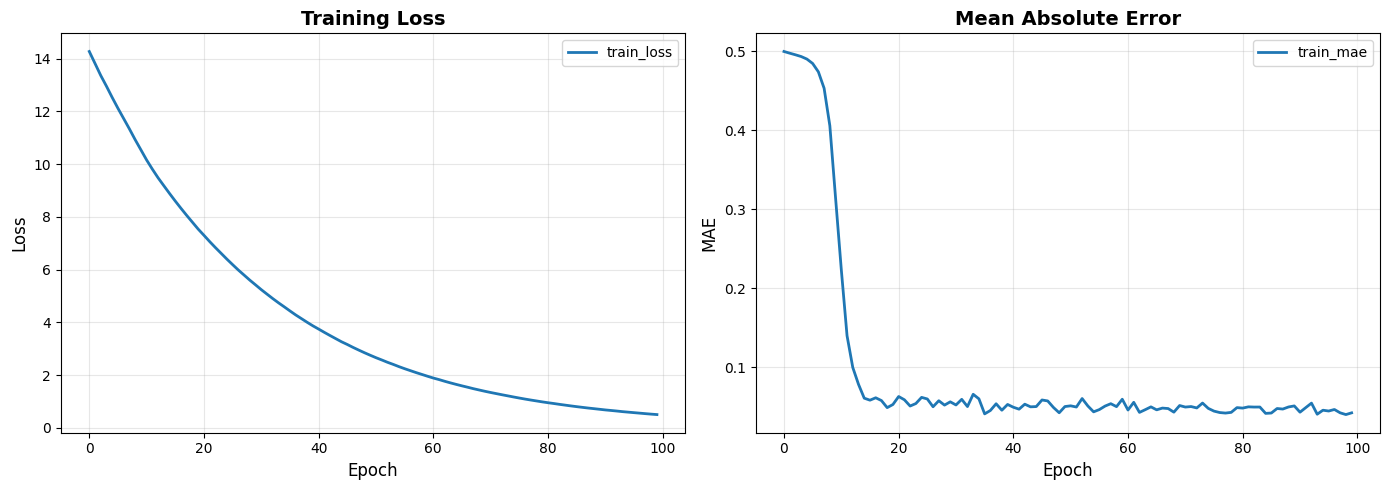


✅ Plot saved to: training_history_improved.png


In [26]:
"""
Plot Training History (Robust - Handle Missing Val Data)
"""

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PLOT 1: Loss
axes[0].plot(history.history['loss'], label='train_loss', linewidth=2)

# Hanya plot val_loss jika ada
if 'val_loss' in history.history:
    axes[0].plot(history.history['val_loss'], label='val_loss', linewidth=2)
    print("✅ Validation loss plotted")
else:
    print("⚠️ Validation loss not available - plotting training loss only")

axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# PLOT 2: MAE
axes[1].plot(history.history['mae'], label='train_mae', linewidth=2)

# Hanya plot val_mae jika ada
if 'val_mae' in history.history:
    axes[1].plot(history.history['val_mae'], label='val_mae', linewidth=2)
    print("✅ Validation MAE plotted")
else:
    print("⚠️ Validation MAE not available - plotting training MAE only")

axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('MAE', fontsize=12)
axes[1].set_title('Mean Absolute Error', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_improved.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Plot saved to: training_history_improved.png")


✅ Loaded CSV: training_history_1104_234340.csv

📊 Columns available:
['epoch', 'loss', 'lr', 'mae', 'val_loss', 'val_lr', 'val_mae']


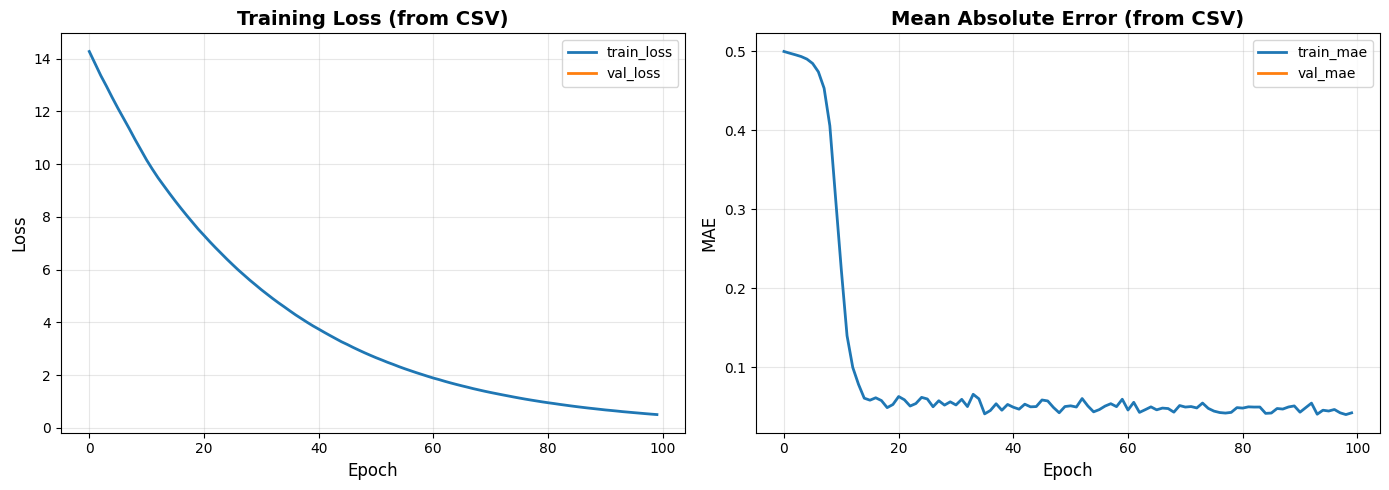


✅ Plot saved from CSV!


In [27]:
"""
Plot dari CSV Training Log
"""

import pandas as pd
import matplotlib.pyplot as plt

# Load CSV log
csv_file = 'training_history_1104_234340.csv'  # ⚠️ Sesuaikan dengan nama file kamu

try:
    df = pd.read_csv(csv_file)
    
    print(f"✅ Loaded CSV: {csv_file}")
    print(f"\n📊 Columns available:")
    print(df.columns.tolist())
    
    # Plot dari CSV
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss
    if 'loss' in df.columns:
        axes[0].plot(df['loss'], label='train_loss', linewidth=2)
    if 'val_loss' in df.columns:
        axes[0].plot(df['val_loss'], label='val_loss', linewidth=2)
    
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training Loss (from CSV)', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # MAE
    if 'mae' in df.columns:
        axes[1].plot(df['mae'], label='train_mae', linewidth=2)
    if 'val_mae' in df.columns:
        axes[1].plot(df['val_mae'], label='val_mae', linewidth=2)
    
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('MAE', fontsize=12)
    axes[1].set_title('Mean Absolute Error (from CSV)', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_history_from_csv.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✅ Plot saved from CSV!")
    
except FileNotFoundError:
    print(f"❌ File not found: {csv_file}")


In [28]:
"""
Print Training Summary
"""

print("\n" + "=" * 80)
print("📊 TRAINING SUMMARY")
print("=" * 80)

# Training metrics
print(f"\n📈 Training Metrics:")
print(f"   Final loss: {history.history['loss'][-1]:.6f}")
print(f"   Final MAE: {history.history['mae'][-1]:.6f}")
print(f"   Best (min) loss: {min(history.history['loss']):.6f}")
print(f"   Best (min) MAE: {min(history.history['mae']):.6f}")

# Validation metrics (jika ada)
if 'val_loss' in history.history:
    print(f"\n🎯 Validation Metrics:")
    print(f"   Final val_loss: {history.history['val_loss'][-1]:.6f}")
    print(f"   Final val_mae: {history.history['val_mae'][-1]:.6f}")
    print(f"   Best (min) val_loss: {min(history.history['val_loss']):.6f}")
    print(f"   Best (min) val_mae: {min(history.history['val_mae']):.6f}")
else:
    print(f"\n⚠️ No validation data recorded during training")

print(f"\nTotal epochs: {len(history.history['loss'])}")
print("=" * 80)



📊 TRAINING SUMMARY

📈 Training Metrics:
   Final loss: 0.504654
   Final MAE: 0.041981
   Best (min) loss: 0.504654
   Best (min) MAE: 0.039797

⚠️ No validation data recorded during training

Total epochs: 100


In [ ]:
"""
Print Training Summary
"""

print("\n" + "=" * 80)
print("📊 TRAINING SUMMARY")
print("=" * 80)

# Training metrics
print(f"\n📈 Training Metrics:")
print(f"   Final loss: {history.history['loss'][-1]:.6f}")
print(f"   Final MAE: {history.history['mae'][-1]:.6f}")
print(f"   Best (min) loss: {min(history.history['loss']):.6f}")
print(f"   Best (min) MAE: {min(history.history['mae']):.6f}")

# Validation metrics (jika ada)
if 'val_loss' in history.history:
    print(f"\n🎯 Validation Metrics:")
    print(f"   Final val_loss: {history.history['val_loss'][-1]:.6f}")
    print(f"   Final val_mae: {history.history['val_mae'][-1]:.6f}")
    print(f"   Best (min) val_loss: {min(history.history['val_loss']):.6f}")
    print(f"   Best (min) val_mae: {min(history.history['val_mae']):.6f}")
else:
    print(f"\n⚠️ No validation data recorded during training")

print(f"\nTotal epochs: {len(history.history['loss'])}")
print("=" * 80)



📊 TRAINING SUMMARY

📈 Training Metrics:
   Final loss: 0.504654
   Final MAE: 0.041981
   Best (min) loss: 0.504654
   Best (min) MAE: 0.039797

⚠️ No validation data recorded during training

Total epochs: 100


KeyError: 'val_loss'

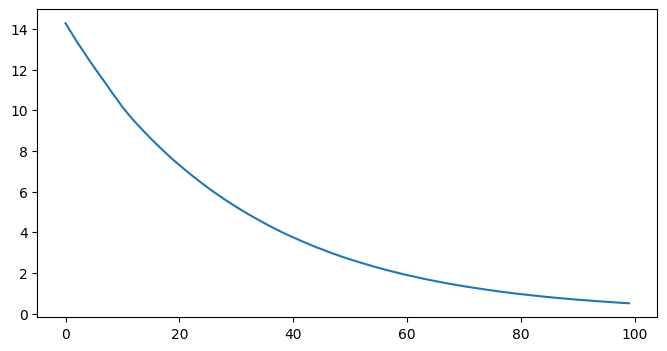

In [24]:
import matplotlib.pyplot as plt

# 1) Plot Loss
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'],    label='train_loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# 2) Plot MAE (atau metric lain yang kamu pakai)
plt.figure(figsize=(8,4))
plt.plot(history.history['mae'],     label='train_mae')
plt.plot(history.history['val_mae'], label='val_mae')
plt.title('Training & Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.show()